
=== Árvore de decisão (Regressão) ===
Features usadas: ['tamanho_m2', 'quartos', 'distancia_centro_km', 'renda_media_regiao']
MAE (Erro Médio Absoluto): R$ 216,285.56
RMSE (Raiz do Erro Quadrático): R$ 416,347.28
R2 Score (Acurácia de Regressão): 0.6586

Comparativo de Preços:
    tamanho_m2  quartos  distancia_centro_km  renda_media_regiao  preco_venda  \
83         145        3                   13                5100       700000   
53         210        4                    6                9400      1650000   
70         210        4                    7                8800      1480000   
45         220        4                    6                9300      1700000   
44          88        2                   19                2700       280000   

    preco_previsto_arvore  
83           7.839286e+05  
53           1.507391e+06  
70           1.507391e+06  
45           1.507391e+06  
44           2.960000e+05  


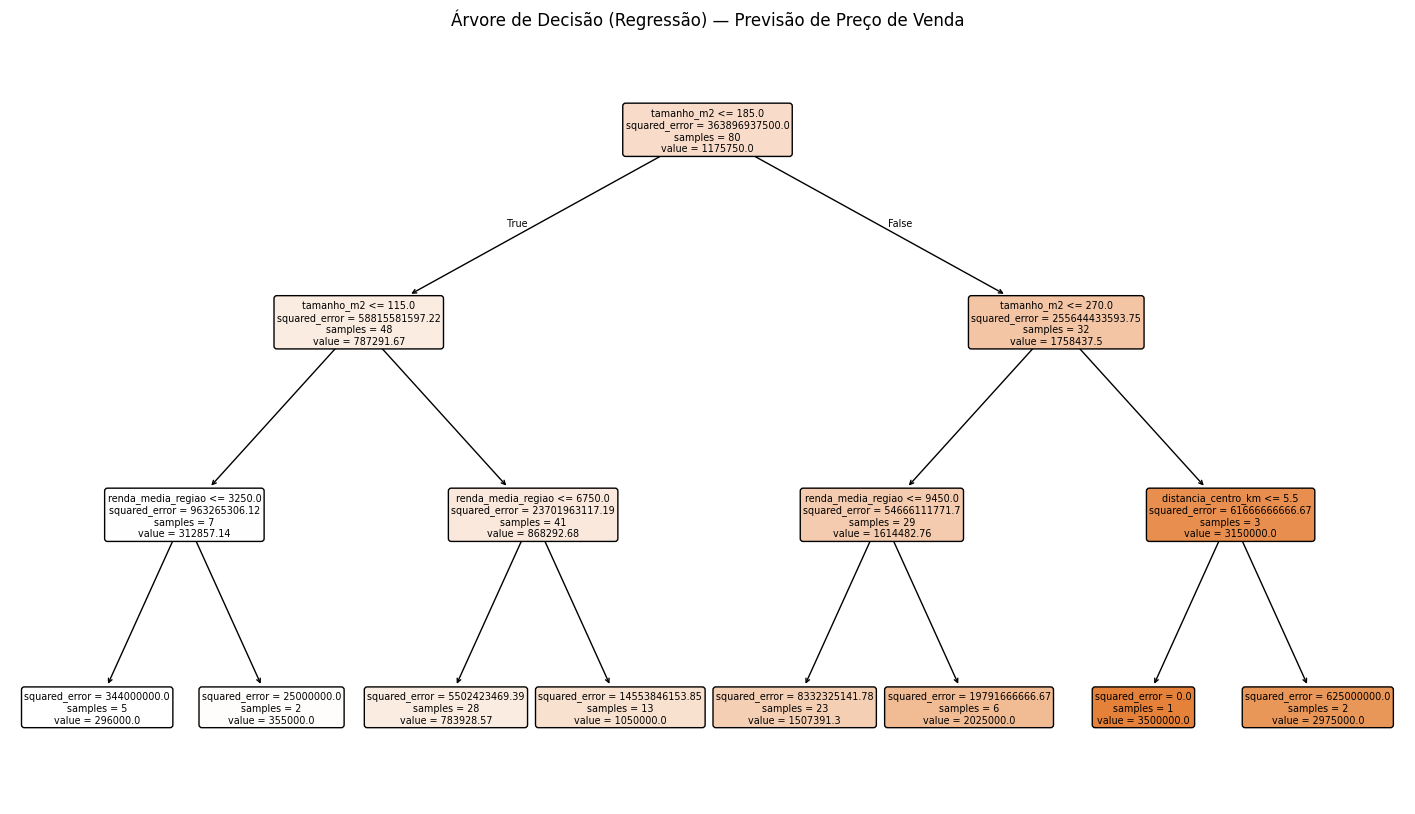

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

RANDOM_STATE = 42
FEATURES = ['tamanho_m2', 'quartos', 'distancia_centro_km', 'renda_media_regiao']
TARGET = 'preco_venda'

url = "https://docs.google.com/spreadsheets/d/1ay2nOuofGz3xPcndKkR--hStjd7iHCN4EPAQsyNi6E8/export?format=csv&gid=0"
df = pd.read_csv(url)

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

tree = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("\n=== Árvore de decisão (Regressão) ===")
print("Features usadas:", FEATURES)

mae = mean_absolute_error(y_test, y_pred_tree)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2 = r2_score(y_test, y_pred_tree)

print(f"MAE (Erro Médio Absoluto): R$ {mae:,.2f}")
print(f"RMSE (Raiz do Erro Quadrático): R$ {rmse:,.2f}")
print(f"R2 Score (Acurácia de Regressão): {r2:.4f}")

test_df = X_test.copy()
test_df[TARGET] = y_test
test_df["preco_previsto_arvore"] = y_pred_tree

print("\nComparativo de Preços:")
print(test_df[FEATURES + [TARGET, "preco_previsto_arvore"]].head())

plt.figure(figsize=(18, 10))
plot_tree(tree, feature_names=FEATURES, filled=True, rounded=True, precision=2)
plt.title("Árvore de Decisão (Regressão) — Previsão de Preço de Venda")
plt.show()